# 👥 K-Nearest Neighbors (KNN) Classifier - Complete Learning Guide

## Overview
K-Nearest Neighbors is a simple yet powerful instance-based (lazy learning) algorithm. It classifies a new point based on the majority class of its k nearest neighbors. Despite its simplicity, KNN can achieve excellent results with proper distance metrics and parameter tuning.

## Key Topics Covered:
1. **KNN Basics** - Instance-based learning fundamentals
2. **Distance Metrics** - Euclidean, Manhattan, Minkowski
3. **Choosing k** - Impact of k on classification
4. **Decision Boundaries** - Visualizing KNN boundaries
5. **Feature Scaling** - Importance for distance metrics
6. **Performance Metrics** - Accuracy, precision, recall, F1
7. **Hyperparameter Tuning** - GridSearchCV for optimal k
8. **Advantages & Disadvantages** - When to use KNN

---

## References:
- [KNN - Wikipedia](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)
- [scikit-learn KNeighborsClassifier](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors)
- [KNN Tutorial](https://www.youtube.com/watch?v=6kZ59XIuc1s)

## 📚 Section 1: Import Libraries

In [15]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 👥 Section 2: KNN Basics


👥 EXAMPLE 1: Basic KNN Classification

✅ KNN (k=5) Results on Iris:
  Accuracy:  0.8222
  Precision: 0.8249
  Recall:    0.8222
  F1-Score:  0.8212


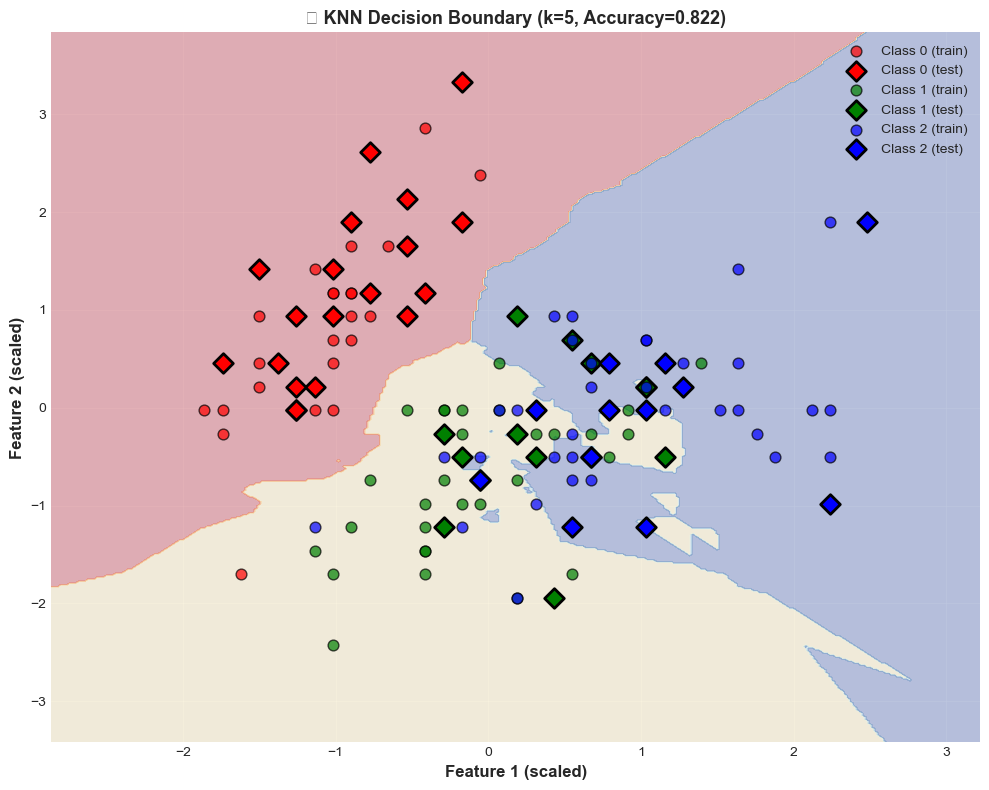

In [16]:
# Example 1: Basic KNN Classification
print("\n" + "="*70)
print("👥 EXAMPLE 1: Basic KNN Classification")
print("="*70)

# Load Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Use first 2 features for visualization
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ KNN (k=5) Results on Iris:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Visualization - Decision boundary
h = 0.02
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

# Plot training data
colors = ['red', 'green', 'blue']
for i in range(3):
    mask_train = y_train == i
    ax.scatter(X_train_scaled[mask_train, 0], X_train_scaled[mask_train, 1],
              c=colors[i], label=f'Class {i} (train)', s=60, alpha=0.7, edgecolors='k')
    
    mask_test = y_test == i
    ax.scatter(X_test_scaled[mask_test, 0], X_test_scaled[mask_test, 1],
              c=colors[i], label=f'Class {i} (test)', s=100, marker='D', edgecolors='k', linewidth=2)

ax.set_xlabel('Feature 1 (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2 (scaled)', fontsize=12, fontweight='bold')
ax.set_title(f'👥 KNN Decision Boundary (k=5, Accuracy={accuracy:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔍 Section 3: Impact of k Parameter


🔍 EXAMPLE 2: Impact of k Parameter

📊 Testing k values:
  k= 1: Train=0.9619, Test=0.7333
  k= 5: Train=0.8667, Test=0.8222
  k=15: Train=0.8286, Test=0.7111
  k=29: Train=0.8000, Test=0.7778


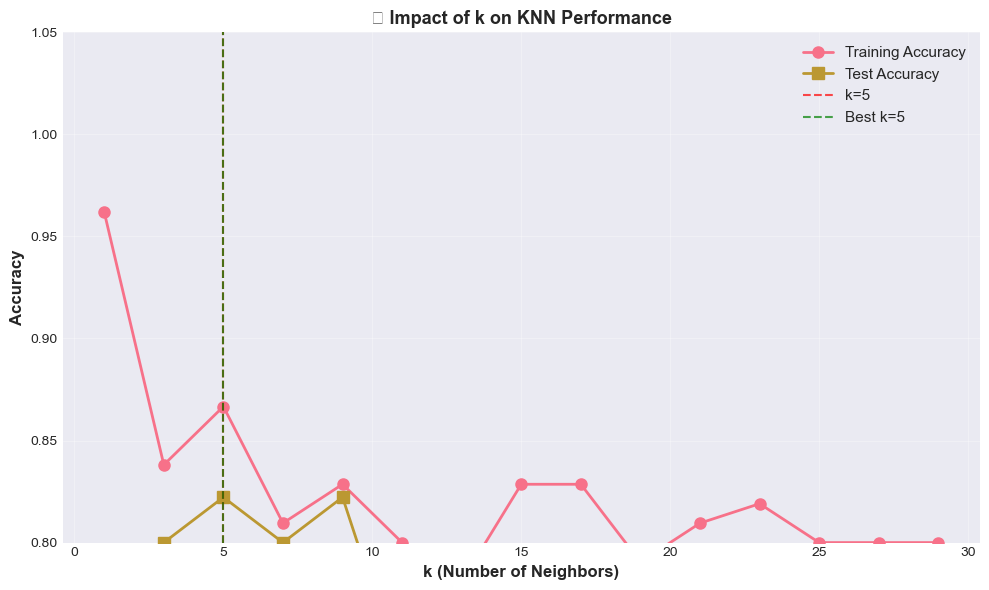


✅ Observations:
  k=1: Perfect training but overfitting (test score lower)
  k too large: Both train and test scores decrease (underfitting)
  Optimal k=5: Best generalization


In [17]:
# Example 2: Impact of k on Classification
print("\n" + "="*70)
print("🔍 EXAMPLE 2: Impact of k Parameter")
print("="*70)

k_values = range(1, 31, 2)
train_scores = []
test_scores = []

print(f"\n📊 Testing k values:")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    train_score = knn_temp.score(X_train_scaled, y_train)
    test_score = knn_temp.score(X_test_scaled, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    if k in [1, 5, 15, 29]:
        print(f"  k={k:2d}: Train={train_score:.4f}, Test={test_score:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
ax.plot(k_values, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax.axvline(x=5, color='r', linestyle='--', alpha=0.7, label='k=5')

best_k = k_values[np.argmax(test_scores)]
ax.axvline(x=best_k, color='g', linestyle='--', alpha=0.7, label=f'Best k={best_k}')

ax.set_xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('🔍 Impact of k on KNN Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

print(f"\n✅ Observations:")
print(f"  k=1: Perfect training but overfitting (test score lower)")
print(f"  k too large: Both train and test scores decrease (underfitting)")
print(f"  Optimal k={best_k}: Best generalization")

## 📏 Section 4: Distance Metrics


📏 EXAMPLE 3: Different Distance Metrics

📊 Testing different distance metrics (k=5):
  euclidean   : Accuracy = 0.8222
  manhattan   : Accuracy = 0.8000
  manhattan   : Accuracy = 0.8000


  minkowski   : Accuracy = 0.8222


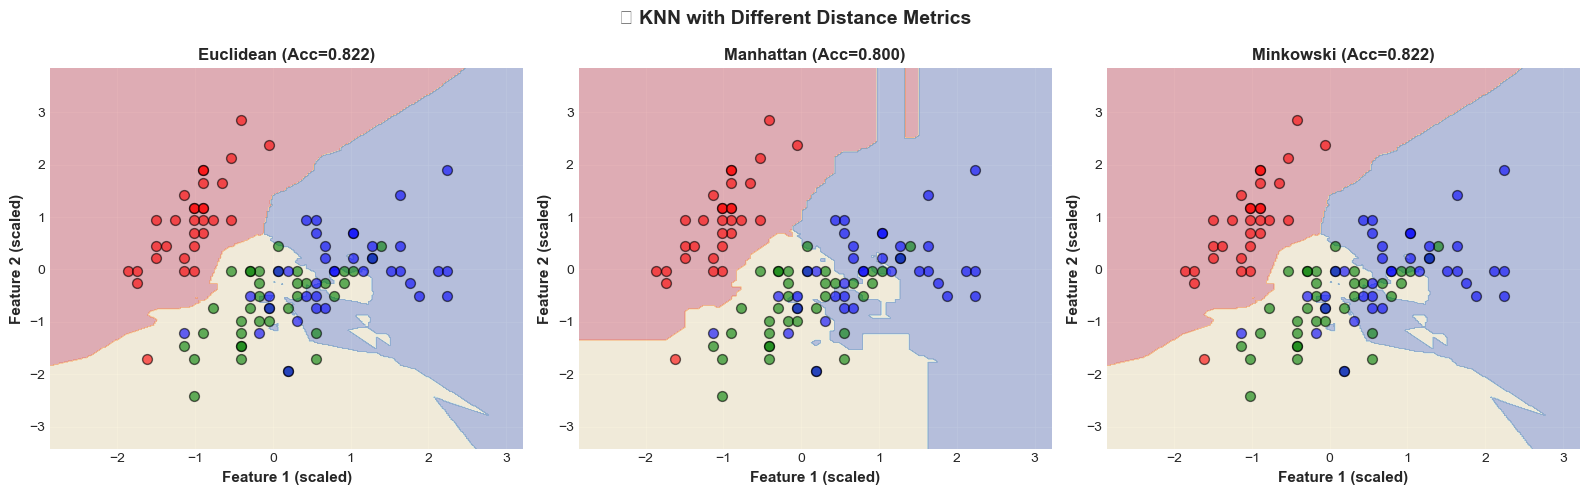


✅ Distance Metrics Summary:
  Euclidean: √(Σ(x_i - y_i)²) - Most common
  Manhattan: Σ|x_i - y_i| - Better for high dimensions
  Minkowski: (Σ|x_i - y_i|^p)^(1/p) - Generalization of both


In [11]:
# Example 3: Comparing Distance Metrics
print("\n" + "="*70)
print("📏 EXAMPLE 3: Different Distance Metrics")
print("="*70)

metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}

print(f"\n📊 Testing different distance metrics (k=5):")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📏 KNN with Different Distance Metrics', fontsize=14, fontweight='bold')

for idx, metric in enumerate(metrics):
    knn_metric = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn_metric.fit(X_train_scaled, y_train)
    y_pred_metric = knn_metric.predict(X_test_scaled)
    accuracy_metric = accuracy_score(y_test, y_pred_metric)
    
    results[metric] = accuracy_metric
    print(f"  {metric:12s}: Accuracy = {accuracy_metric:.4f}")
    
    # Decision boundary
    ax = axes[idx]
    Z_metric = knn_metric.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_metric = Z_metric.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z_metric, alpha=0.3, cmap='RdYlBu')
    
    for i in range(3):
        mask_train = y_train == i
        ax.scatter(X_train_scaled[mask_train, 0], X_train_scaled[mask_train, 1],
                  c=colors[i], s=50, alpha=0.6, edgecolors='k')
    
    ax.set_xlabel('Feature 1 (scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Feature 2 (scaled)', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.capitalize()} (Acc={accuracy_metric:.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Distance Metrics Summary:")
print(f"  Euclidean: √(Σ(x_i - y_i)²) - Most common")
print(f"  Manhattan: Σ|x_i - y_i| - Better for high dimensions")
print(f"  Minkowski: (Σ|x_i - y_i|^p)^(1/p) - Generalization of both")

## 🎯 Section 5: KNN on Binary Classification


🎯 EXAMPLE 4: KNN Binary Classification (Breast Cancer)

✅ KNN (k=5) Results on Breast Cancer:
  Accuracy:  0.9591
  Precision: 0.9633
  Recall:    0.9722
  F1-Score:  0.9677
  ROC-AUC:   0.9787

✅ KNN (k=5) Results on Breast Cancer:
  Accuracy:  0.9591
  Precision: 0.9633
  Recall:    0.9722
  F1-Score:  0.9677
  ROC-AUC:   0.9787


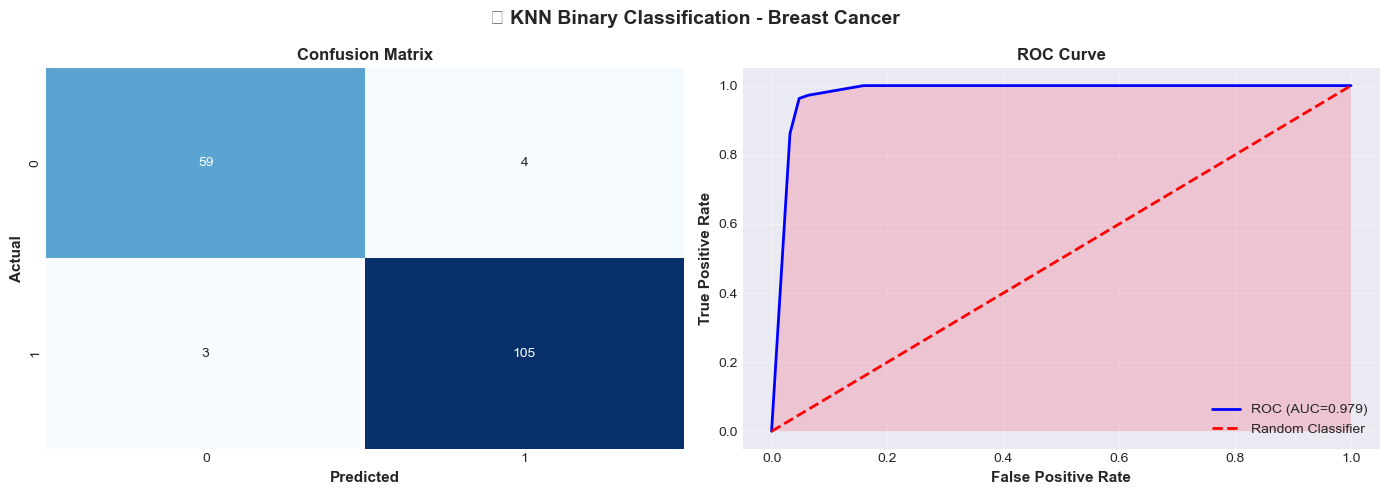

In [12]:
# Example 4: KNN on Breast Cancer Dataset
print("\n" + "="*70)
print("🎯 EXAMPLE 4: KNN Binary Classification (Breast Cancer)")
print("="*70)

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# Split and scale
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# KNN classifier
knn_cancer = KNeighborsClassifier(n_neighbors=5)
knn_cancer.fit(X_train_c_scaled, y_train_c)
y_pred_cancer = knn_cancer.predict(X_test_c_scaled)
y_pred_proba_cancer = knn_cancer.predict_proba(X_test_c_scaled)[:, 1]

# Metrics
accuracy_c = accuracy_score(y_test_c, y_pred_cancer)
precision_c = precision_score(y_test_c, y_pred_cancer)
recall_c = recall_score(y_test_c, y_pred_cancer)
f1_c = f1_score(y_test_c, y_pred_cancer)
roc_auc_c = roc_auc_score(y_test_c, y_pred_proba_cancer)

print(f"\n✅ KNN (k=5) Results on Breast Cancer:")
print(f"  Accuracy:  {accuracy_c:.4f}")
print(f"  Precision: {precision_c:.4f}")
print(f"  Recall:    {recall_c:.4f}")
print(f"  F1-Score:  {f1_c:.4f}")
print(f"  ROC-AUC:   {roc_auc_c:.4f}")

# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 KNN Binary Classification - Breast Cancer', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_cancer)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba_cancer)
ax = axes[1]
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc_c:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔧 Section 6: Hyperparameter Tuning


🔧 EXAMPLE 5: Hyperparameter Tuning with GridSearchCV

🔍 Performing GridSearchCV...

✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
  Best CV Score: 0.9622

✅ Best Model Test Accuracy: 0.9591

✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
  Best CV Score: 0.9622

✅ Best Model Test Accuracy: 0.9591


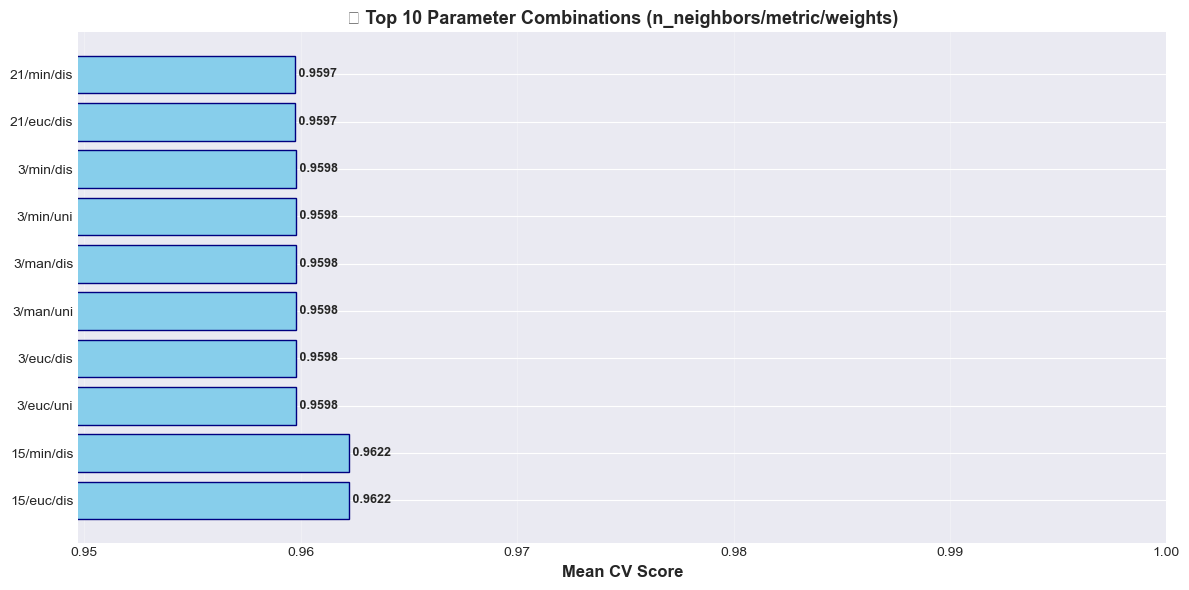

In [13]:
# Example 5: GridSearchCV for KNN Tuning
print("\n" + "="*70)
print("🔧 EXAMPLE 5: Hyperparameter Tuning with GridSearchCV")
print("="*70)

# Parameters to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

# GridSearchCV
print(f"\n🔍 Performing GridSearchCV...")
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_c_scaled, y_train_c)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

# Best model
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_c_scaled)
accuracy_best = accuracy_score(y_test_c, y_pred_best)

print(f"\n✅ Best Model Test Accuracy: {accuracy_best:.4f}")

# Visualization - Top 10 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_10 = results_df.nlargest(10, 'mean_test_score')[['param_n_neighbors', 'param_metric', 'param_weights', 'mean_test_score']]

fig, ax = plt.subplots(figsize=(12, 6))

top_10_display = top_10.copy()
top_10_display['params'] = (top_10_display['param_n_neighbors'].astype(str) + '/' + 
                             top_10_display['param_metric'].str[:3] + '/' + 
                             top_10_display['param_weights'].str[:3])

bars = ax.barh(range(len(top_10_display)), top_10_display['mean_test_score'], color='skyblue', edgecolor='navy')
ax.set_yticks(range(len(top_10_display)))
ax.set_yticklabels(top_10_display['params'], fontsize=10)
ax.set_xlabel('Mean CV Score', fontsize=12, fontweight='bold')
ax.set_title('🔧 Top 10 Parameter Combinations (n_neighbors/metric/weights)', fontsize=13, fontweight='bold')
ax.set_xlim([min(top_10_display['mean_test_score'])-0.01, 1.0])
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, top_10_display['mean_test_score'])):
    ax.text(score, i, f' {score:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 📋 Section 7: KNN - Advantages & Disadvantages

### ✅ Advantages:
1. **Simple to understand** - Very intuitive algorithm
2. **No training phase** - Lazy learning, just stores data
3. **Works for multi-class** - Easy to extend to multiple classes
4. **Flexible distance metrics** - Can use any distance measure
5. **No assumptions** - Makes no assumptions about data distribution
6. **Weighted KNN** - Can weight closer neighbors more heavily

### ❌ Disadvantages:
1. **Slow prediction** - O(n) for each prediction
2. **Needs entire dataset** - Stores all training data (memory intensive)
3. **Curse of dimensionality** - Performance degrades in high dimensions
4. **Feature scaling required** - Distance metrics depend on scale
5. **Sensitive to k** - Results vary with k selection
6. **Imbalanced data** - Majority class dominates predictions

### When to Use:
- Small to medium datasets
- Non-linear decision boundaries needed
- Low to medium dimensionality
- Quick prototyping/baseline
- When interpretability is important
- Classification and regression both

In [14]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "KNN: Instance-based (lazy learning) classification algorithm",
    "Algorithm: Find k nearest neighbors → use majority vote",
    "No training phase - just stores data (lazy learning)",
    "Prediction time: O(n) - linear with dataset size (slow!)",
    "k selection critical: k=1 overfits, large k underfits",
    "Distance metrics matter: Euclidean, Manhattan, Minkowski",
    "Always scale features! Distance metrics scale-dependent",
    "Weighted KNN: Closer neighbors contribute more (weights by 1/distance)",
    "Curse of dimensionality: Distance becomes meaningless in high dims",
    "Imbalanced data issue: Majority class tends to dominate",
    "Memory intensive: Must store entire training dataset",
    "Good for baselines and when decision boundaries non-linear"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. KNN: Instance-based (lazy learning) classification algorithm

 2. Algorithm: Find k nearest neighbors → use majority vote

 3. No training phase - just stores data (lazy learning)

 4. Prediction time: O(n) - linear with dataset size (slow!)

 5. k selection critical: k=1 overfits, large k underfits

 6. Distance metrics matter: Euclidean, Manhattan, Minkowski

 7. Always scale features! Distance metrics scale-dependent

 8. Weighted KNN: Closer neighbors contribute more (weights by 1/distance)

 9. Curse of dimensionality: Distance becomes meaningless in high dims

10. Imbalanced data issue: Majority class tends to dominate

11. Memory intensive: Must store entire training dataset

12. Good for baselines and when decision boundaries non-linear

